#### **SVD - Singular Value Decomposition və PCA ilə əlaqəsi, Rank nƏdir, SVD ilə aşağı Rank probleminin həlli, N(0, 1) nədir?**

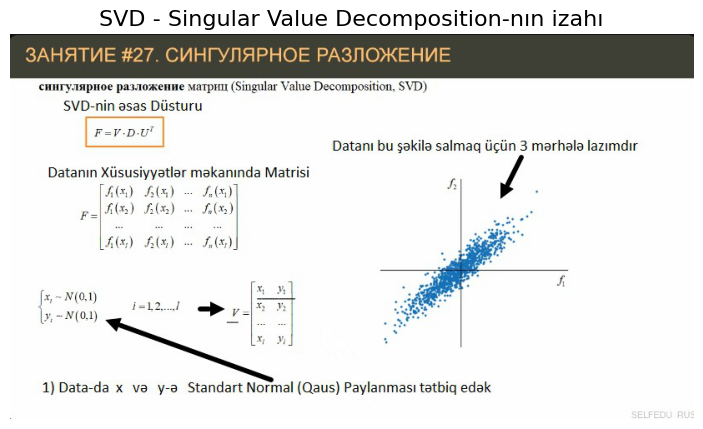

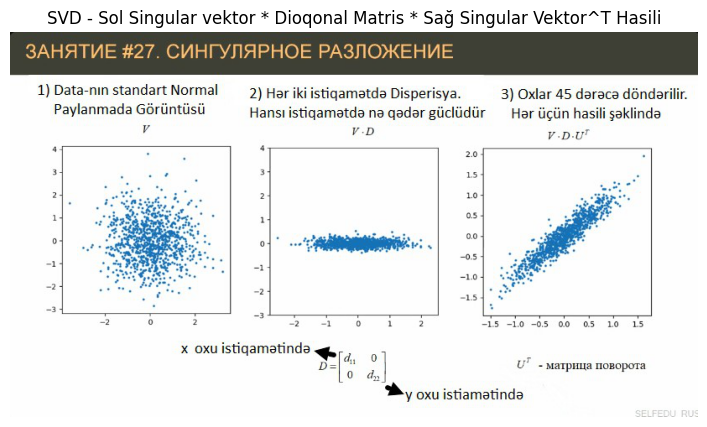

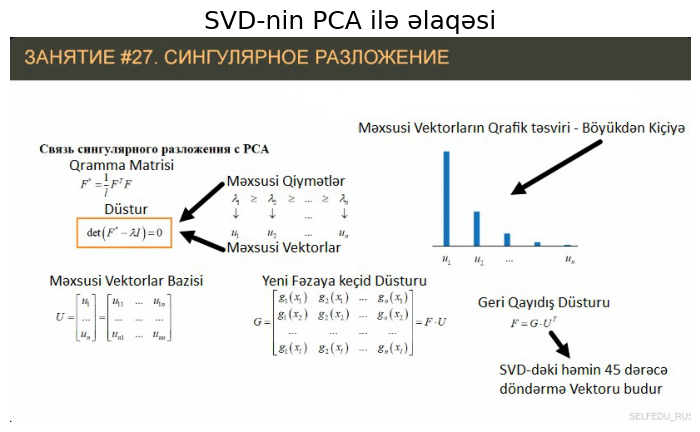

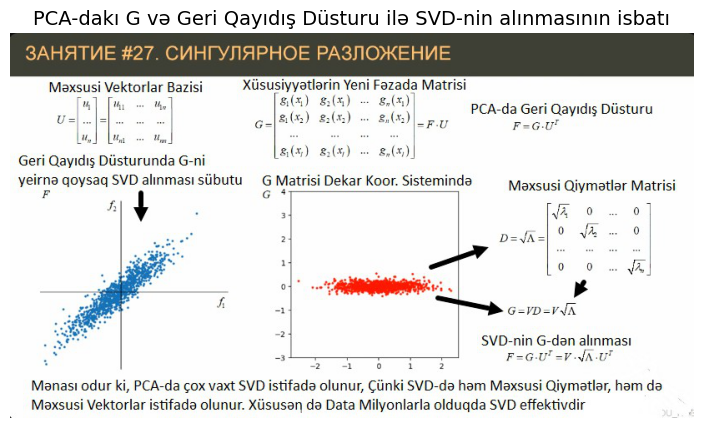

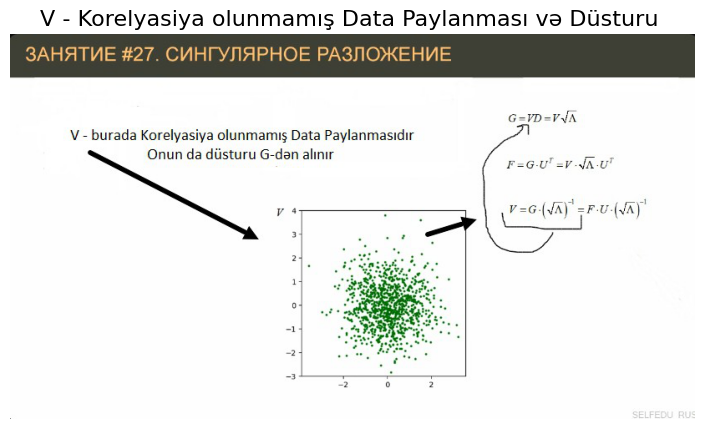

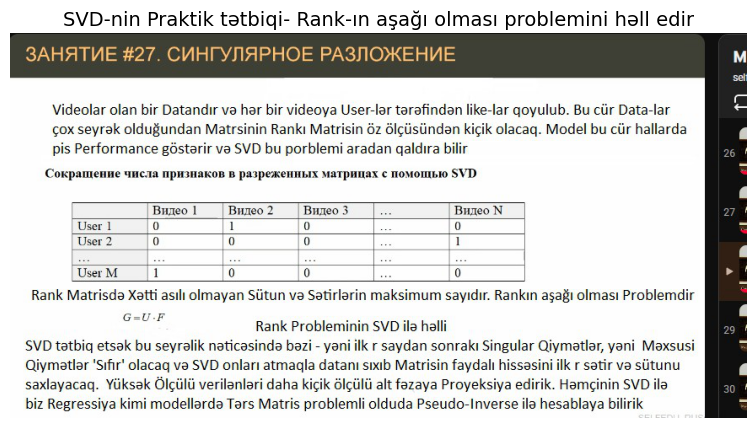

In [6]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Selfedu\Pictures\ML_27_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 7):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for i, image in enumerate(image_list):
    if i == 100:
        plt.figure(figsize=(8.8, 4))          
    else:     
        plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü    
        
    if i < 1:
        plt.title("""SVD - Singular Value Decomposition-nın izahı""", size='16')
    elif i < 2:
        plt.title("""SVD - Sol Singular vektor * Dioqonal Matris * Sağ Singular Vektor^T Hasili""", size='12')
    elif i < 3:
        plt.title("""SVD-nin PCA ilə əlaqəsi""", size='18')
    elif i < 4:
        plt.title("""PCA-dakı G və Geri Qayıdış Düsturu ilə SVD-nin alınmasının isbatı""", size='14')
    elif i < 5:
        plt.title("""V - Korelyasiya olunmamış Data Paylanması və Düsturu """, size='16')
    elif i < 6:
        plt.title("""SVD-nin Praktik tətbiqi- Rank-ın aşağı olması problemini həll edir""", size='14')        

    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()

#### **$N(0, 1)$ əslində Standart Normal Paylanmanı ($Z$-paylanması) xarakterizə edir**
- #### **Adi halda Normal paylanmada 0 və 1 qəbul olunmur, sadəcə standartlaşdırmaq üçün seçilir ki, hesablamalar asan olsun.**

> **Normal paylanmada (Qauss paylanması) ortalamanın ($\mu$) 0, dispersiyanın ($\sigma^2$) isə 1 qebul edilməsi, əslində Standart Normal Paylanmanı ($Z$-paylanması) xarakterizə edir. Bu, təsadüfi bir seçim deyil, həm riyazi sadəlik, həm də praktiki ehtiyaclardan irəli gəlir.**

<br>

- **Bunun əsas səbəblərini aşağıdakı bəndlərlə izah etmək olar:**

#### **1. Standartlaşdırma (Z-score) - Əsas məsəslə burdadır**
- **Hər bir normal paylanmanın fərqli ortalaması və dispersiyası ola bilər (məsələn, insanların boyu ilə çəkisi fərqli miqyaslardadır). Müxtəlif vahidlərlə ölçülən məlumatları müqayisə etmək üçün biz onları "eyni dilə" çeviririk.**
$$Z = \frac{X - \mu}{\sigma}$$
> **Bu düsturu tətbiq etdikdə, istənilən normal paylanma mərkəzi 0 olan və vahid dispersiyalı formaya düşür.**

<br>

#### 💎 **Əsas Real Praktiki səbəblər:**

<br>

#### **Miqyas fərqini aradan qaldırır**

- **Məsələn:**

    * **Maaş → 1000–5000**
    * **Yaş → 18–60**

    - **Bunlar fərqli scale-dədir. Standartlaşdıranda:**

        * **hər ikisi eyni “ölçü vahidinə” düşür**

<br>

#### **Orta ətrafında ölçmək olur**

- **Standartlaşdırma:**
$$
Z = \frac{X - \mu}{\sigma}
$$

- **→ bu sənə deyir:**

    * **“X orta dəyərdən neçə σ uzaqdadır?”**

- **Yəni:**

    * **Z = 2 → ortadan 2 standart sapma yuxarı**
    * **Z = -1 → ortadan 1 aşağı**

<br>

#### **Bütün normal paylanmalar → eyni formaya düşür**

- **İstənilən:**
$
N(\mu, \sigma^2)
$

- **→ çevrilir:**
$
N(0,1)
$

- **Bu da deməkdir:**

    * **bircə **standart normal cədvəl** ilə bütün ehtimalları hesablamaq olur**

<br>

#### **ML modelləri üçün vacibdir**

- **Xüsusilə:**

  * **SVM**
  * **Logistic Regression**
  * **KNN**
  * **PCA**

> **Bunlar məsafə və ya miqyasdan asılıdır**

> **→ scale fərqi olsa model səhv “prioritet” verəcək**

<br>

#### **Qısa nəticə:**

- **Standartlaşdırma seçilir ki:**

    * **fərqli ölçülər eyniləşsin**
    * **orta ilə müqayisə mümkün olsun**
    * **hesablamalar sadələşsin**
    * **modellər düzgün işləsin**
    
<br>

#### **2. Riyazi Hesablamaların Sadələşməsi**
- **Normal paylanmanın ehtimal sıxlıq funksiyası kifayət qədər mürəkkəbdir:**
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$
- **Əgər biz $\mu = 0$ və $\sigma = 1$ qəbul etsək, düstur xeyli sadələşir:**
$$f(z) = \frac{1}{\sqrt{2\pi}} e^{-\frac{z^2}{2}}$$
- **Bu sadələşmə inteqral hesablamalarını və statistik cədvəllərin (Z-table) yaradılmasını mümkün edir.**

<br>

#### **3. Müqayisə imkanı**
- **Təsəvvür edin ki, iki fərqli modeliniz var: birinin səhvi manatla, digərininki isə faizlə ölçülür. Onları birbaşa müqayisə edə bilməzsiniz. Amma hər ikisini $N(0, 1)$ formasına gətirdikdə, "kənarlaşmaların" (outliers) dərəcəsini eyni meyarla ölçə bilirsiniz.**

<br>

#### **4. Alqoritmlərin Effektivliyi**
- **Maşın öyrənməsində (məsələn, Gradient Descent istifadə edən alqoritmlərdə) məlumatların ortalamasının 0 və dispersiyasının 1 olması optimallaşdırma prosesini sürətləndirir. Funksiya "oval" deyil, daha "dairəvi" formaya düşdüyü üçün alqoritm qlobal minimuma daha düz xətt boyunca gedir.**

<br>

#### **5. "68-95-99.7" Qaydası**
- **Standart normal paylanmada məlumatların harada yerləşdiyini bilmək çox asandır:**
    * **Məlumatın $\quad$ 68%-i  $\quad$ -1 və +1 $\quad$ arasındadır.**
    * **Məlumatın $\quad$ 95%-i $\quad$ -2 və +2 $\quad$ arasındadır.**
    * **Məlumatın $\quad$ 99.7%-i $\quad$  -3 və +3 $\quad$ arasındadır.**

> **Bu sabitlik statistik testlərin (məsələn, p-value hesablanması) aparılmasını standart hala gətirir.**

> **Qısacası, $\mu=0$ və $\sigma=1$ seçimi kainatın bir qaydası deyil, riyaziyyatçıların və data elm adamlarının həyatını asanlaşdıran bir referans nöqtəsidir**.

<br>

- **Qısa desək:**
> **standartlaşdırmaq ona görə seçilir ki, bütün fərqli dataları eyni ölçüyə salaq və müqayisə + hesablama asan olsun.**

### **Singular Value Decomposition (SVD)**

- **SVD-ni ML dünyasında ən mükəmməl şəkildə belə ifadə edə bilərik:**
    > - **SVD — böyük və qarmaqarışıq verilənləri onların ən vacib istiqamətlərini göstərən "məxsusi vektorlara" və bu istiqamətlərin gücünü ölçən "məxsusi qiymətlərə" parçalayaraq, datanın içindəki gizli mənanı üzə çıxaran bir filtrdir.**

    > - **Bu prosesi belə təsəvvür et: Məxsusi vektorlar datanın içindəki əsas "mövzuları" müəyyən edir, məxsusi qiymətlər isə bu mövzuların nə dərəcədə əhəmiyyətli olduğunu bizə deyir; beləliklə, biz ən kiçik qiymətli (əhəmiyyətsiz) hissələri ataraq datanı sadələşdiririk.**
    
<br>

- **Riyazi Anlamda:**
> **Xətti Cəbrin "İsveçrə bıçağı" sayılan Singular Value Decomposition (SVD) - təkrarolunmaz qiymətlərə ayrılmadır. SVD-nin əsas fəlsəfəsi budur: Hər hansı bir matrisi (məlumatı) üç fərqli həndəsi hərəkətə (fırlanma, dartılma və yenidən fırlanma) parçalamaq olar. SVD (Singular Value Decomposition) xətti cəbrin "İsveç bıçağı" kimidir – hər işə yarayır. SVD bizə deyir ki, istənilən (hətta kvadrat olmayan) matrisi üç xüsusi matrisin hasilinə parçalamaq olar.**

- **Şəkildəki düsturu və onun hər bir komponentini cüt-cüt və məntiqi ardıcıllıqla izah edək:**

$$F = V \cdot D \cdot U^T$$

<br>

#### **🔥 Əsas fikir (ən vacib hissə)**

- **SVD deyir ki:**

> **A matrisi = Korelyasiya olunmamış Paylanma (V), uzat ($Σ$), sonra yenə fırlat ($U^T$)**

<br>

#### **1. Komponentlərin Mənası**
* **$F$ ($m \times n$) -** **Sizin əsas məlumat matrisiniz.**
* **$V$ ($m \times m$): Sol sinqulyar vektorlar:** **Bu, giriş məkanındakı (sütunlar/xüsusiyyətlər arası əlaqə) oxları göstərir. Datanın daxili strukturunu, yəni xüsusiyyətlərin bir-biri ilə necə kombinasiya olunduğunu izah edir. Adətən Korelyasiya olunmamış Data Paylanması.**
* **$D$ (Sinqulyar Qiymətlər - Diagonal) ($m \times n$) -**  **Bu, diaqonal matrisdir. Onun daxilindəki rəqəmlər hər bir yeni oxun nə qədər "vacib" və ya "güclü" olduğunu göstərir. Ən böyük rəqəm ən çox informasiya daşıyan istiqamətdir. Burada yalnız diaqonalda qiymətlər var ($\sigma_1, \sigma_2, ...$). Bu qiymətlər məlumatın hansı istiqamətdə nə qədər "vacib" və ya "güclü" olduğunu göstərir. Həndəsi olaraq dartılmanı (scaling) ifadə edir.**
* **$U^T$ ($n \times n$). Sağ sinqulyar vektorların transponiri -** **Bu matris çıxış məkanındakı (sətirlər arası əlaqə) 45 dərəcə döndərilmiş yeni oxları göstərir. Bu, datanın "harada" (hansı müşahidələrdə) qruplaşdığını izah edir. Bu matris ortoqonaldır (sütunları bir-birinə perpendikulyardır və uzunluqları 1-dir). Həndəsi olaraq fırlanmanı (rotation) ifadə edir.**


<br>

#### **2.1 Niyə məhz $U^T$ (Transponirə olunmuş form)?**

- **"Niyə adi $U$ yox, $U^T$?". Bunun 3 əsas səbəbi var:**

    - **1. Geri Dönüşümlülük (Ortonormallıq): SVD-də $U$ matrisi ortonormaldır. Ortonormal matrislərin ən böyük xüsusiyyəti odur ki, onların tərsi ($U^{-1}$) elə onların transponirə olunmuşuna ($U^T$) bərabərdir. Biz matrisi parçalayırıqsa, onu elə parçalamalıyıq ki, vurduqda geri qayıtsın.**
    - **2.  Koordinat Çevrilməsi: Xətti cəbirdə bir vektoru yeni koordinat sisteminə köçürmək üçün onu yeni bazis vektorlarına proyeksiyalamalıyıq. Proyeksiya isə skalyar hasildir. Matris vurulmasında $U^T \cdot x$ əməliyyatı əslində $x$ vektorunun $U$-nun hər bir sütunu ilə skalyar hasilini tapmaq deməkdir.**
    - **3.  Həndəsi Ardıcıllıq: SVD prosesi həndəsi olaraq 3 addımdan ibarətdir:**
        * **Paylanma ($V$):** **Datanın  Korelyasiya olunmamış Paylanamsı.**
        * **Dartılma ($D$):** **Datanı vacib istiqamətlər üzrə uzadır.**
        * **Yenidən Döndərmə ($U^T$):** **Datanı hədəf məkanına uyğunlaşdırır.**
        

<br>

#### **2.2 Niyə məhz $U^T$ (Transponir)?**

- **Bu sual SVD-nin mahiyyətini anlamaq üçün çox kritikdir. Bunun üç əsas səbəbi var:**

- **A. Ortoqonallıq və Tərs Matris Münasibəti:**
    - **SVD-nin məqsədi matrisi elə hissələrə ayırmaqdır ki, həmin hissələr "təmiz" (perpendikulyar) qalsın. Ortoqonal matrislərin ($U$) ən böyük xüsusiyyəti budur:**
        $$U^{-1} = U^T$$
        - **Yəni, bir matrisi transponir etmək, həndəsi olaraq edilən fırlanmanı geri qaytarmaq (reverse) deməkdir. Düsturda $U^T$ yazmaqla biz əslində sistemi yeni bir koordinat oxuna keçiririk, $D$ ilə ölçüləri dəyişirik.**

<br>

- **B. Bazis Dəyişimi (Change of Basis):**
    - **Təsəvvür edin ki, məlumatlarınız dağınıqdır.**
    - **1. $V$ əməliyyatı məlumatı elə bir vəziyyətə gətirir ki, onun əsas oxları bizim standart koordinat oxlarımızla üst-üstə düşsün.**
    - **2.  $D$ (diaqonal) həmin oxlar boyu məlumatı uzadır və ya sıxır.**
    - **3.  $U^T$ isə bu yeni formanı yekun hədəf mövqeyinə fırladır.**
    > **Əgər $U^T$ yox, sadəcə $U$ olsaydı, bu zəncirvari həndəsi transformasiya məntiqi pozulardı.**

<br>

- **C. Matris Vurma Uyğunluğu:**
    - **Əgər $F$ matrisi $m \times n$ ölçüdədirsə:**
        * **$V$ matrisi $m \times m$**
        * **$D$ matrisi $m \times n$**
        * **$U$ matrisi $n \times n$ olmalıdır.**
        * **Vurma əməliyyatının ($m \times m \cdot m \times n \cdot n \times n$) baş tutması və nəticənin $m \times n$ alınması üçün sondakı matrisin ölçüləri və vektorial istiqaməti mütləq transponir halında olmalıdır.**

<br>

#### **3. SVD-nin "Məntiqi" nədir? (Nə xeyri var?)**

- **SVD bizə deyir ki: "Mənə istənilən mürəkkəb matrisi ver, mən onu elə sadələşdirim ki, sən ən vacib məlumatın harda olduğunu görəsən. SVD əslində mürəkkəb bir matrisi daha sadə və idarə oluna bilən "qatlara" ayırır:**

    * **Data Compression (Datanın Sıxılması):** **Əgər $D$ matrisində bəzi rəqəmlər çox kiçikdirsə, biz onları sıfır sayaraq matrisin böyük hissəsini ata bilərik. Məsələn, bir şəkli SVD ilə parçalayıb ən vacib 10 istiqaməti saxlasaq, şəklin keyfiyyəti az dəyişər, amma yaddaşda tutduğu yer 100 dəfə azalar.**
    * **Tövsiyə Sistemləri (Netflix/Spotify):** **SVD istifadəçilərin (sətirlər) və kinoların (sütunlar) arasındakı gizli əlaqələri tapır. $U^T$ burada kinoların hansı gizli janrlara (aksiyon, dram və s.) aid olduğunu üzə çıxarır.**
    * **Səs-küyün təmizlənməsi (Denoising): Kiçik sinqulyar qiymətlər adətən səs-küyü (noise) təmsil edir. Onları atmaqla məlumatı təmizləyirik. Datadakı xırda detalları (kiçik sinqulyar qiymətləri) silərək əsas strukturu qoruyub saxlayır.**

> **SVD bir növ matrisin DNT analizidir. Onu hissələrə ayırır ki, daxilindəki gizli strukturu görə bilək.**

<br>

- **Xülasə:** 
> $F = V \cdot D \cdot U^T$ **düsturu datanı "Korelyasiya olnmamış Paylanma ($V$), Dart ($D$), Yenidən Döndər ($U^T$)" əməliyyatına məruz qoyur. $U^T$ yazılmasının səbəbi isə həm riyazi proyeksiyanı (skalyar hasil) yerinə yetirmək, həm də matrisin ortonormal xüsusiyyətindən istifadə edərək hesablamanı asanlaşdırmaqdır.**

### **PCA ilə SVD arasındakı Riyazi əlaqə**

> **Şəkil Əsas Komponentlər Analizi (PCA) ilə Təkili Dəyərlərin Ayrılması (SVD) arasındakı riyazi əlaqəni çox gözəl vizuallaşdırır. Bu "mərhələlər" məsələsi əslində məlumatın koordinat sistemində necə hərəkət etdiyini (fırlanma və genişlənmə) göstərir.**

<br>

- **Addım-addım bu keçidləri və fərqləri izah edək:**


#### **$G$ Matrisi nədir? (Ağardılmış Məlumat - Whitened Data)**
- **Şəkildəki qrafiklərdə görürsən ki, $F$ qrafikində nöqtələr bir-birilə korrelyasiyadadır (diaqonal boyu uzanıblar). $G$ qrafikində isə nöqtələr artıq dairəvi (və ya elliptik olmayan) formadadır və oxlar boyu səpiliblər.**

* **Şəkildəki $G$ matrisinin içindəki $g_n(x_i)$ elementləri bizim skorlarımızdır**. 
* $G$**-nin ənənəvi düsturu:**
    $$G = F \cdot U$$
    - **Burada $U$ məxsusi vektorlar matrisidir. Bu əməliyyat datanı elə fırladır ki, yeni oxlar (komponentlər) arasındakı korrelyasiya sıfıra enir.**
* **PCA-nın ənənəvi Geri Qayııdış düstu:** 
        $$F = G \cdot U^T$$

<br>

#### **$G$ Matrisinə həmçinin SVD-nin ikinci mərhələsi kimi yanaşmaq olar**
$$G = V \cdot D = V \cdot \sqrt{\Lambda}$$
* **$D = \sqrt{\Lambda}$** **matrisi məxsusi qiymətlərin ($\sqrt{\Lambda}$) köklərindən ibarətdir.**
* **$D$ (və ya $\Sigma$):** **Datanın hər bir ox boyu nə qədər "dartıldığını" (varyansı) göstərir.**
* **$V$:** **Korelyasiya olunmamış Paylanma.**

<br>

#### **PCA-da 2 mərhələ vs SVD-də 3 mərhələ - SVD-nin sanki $G$-dən formalaşan düsturu**
- **PCA-da isə sanki 2 mərhələ**

<br>

* **PCA (2 addım):**
    * **Burada $G$ artıq öz daxilində həm $V$-ni (istiqaməti), həm də $D$-ni (miqyası/enerjini) saxlayır:**
            $$G = V \cdot D = V \cdot \sqrt{\Lambda}$$
    * **Yəni $G$ artıq "hazırlanmış", lazımi qədər böyüdülmüş və fırladılmış datadır. Bizə sadəcə onu əsas oxlara ($U^T$) proyeksiyalamaq qalıb.**
    
<br>

* **SVD (3 addım):** 
    * **PCA-nın ənənəvi Geri Qayıdış düstu:** 
        $$F = G \cdot U^T$$
    * $G$ **-nin SVD-nin ikinci mərhələsi kimi yanaşma düsturu:**    
        $$G = V \cdot D = V \cdot \sqrt{\Lambda}$$
    * **SVD-nin sanki $G$-dən formalaşan düsturu**    
    $$F = G \cdot U^T=  V \cdot \sqrt{\Lambda} \cdot U^T$$
    
    > **Əslinda riyazi olaraq PCA və SVD hər ikisi eyni yerə çıxır, sadəcə baxış bucağı fərqlidir.**

<br>

#### **Niyə SVD daha effektivdir?**
> **Praktikada, xüsusən `sklearn` kimi kitabxanalarda PCA hesablanarkən Kovariasiya Matrisinin Məxsusi Qiymətlərini $\det(F^* - \lambda I) = 0$ düsturu ilə tapmaq əvəzinə, birbaşa datanın özünə SVD tətbiq olunur. Bunun səbəbləri:**
> - **1.  Hesablama dəqiqliyi:Kovariasiya matrisini ($F^T F$) hesablamaq bəzən çox böyük və ya çox kiçik rəqəmlərə (numerical instability) səbəb olur.**
> - **2 SVD birbaşa $F$ üzərində işlədiyi üçün daha stabil nəticə verir.**
> - **3.  Effektivlik: SVD alqoritmləri (məsələn, Randomized SVD) çox böyük matrislərdə bütün məxsusi qiymətləri hesablamağa ehtiyac duymadan ən vacib olanları tez tapa bilir**.

<br>

- **Xülasə:**
> **Şəkildə gördüyün $F = G \cdot U^T$ düsturunda $G$-ni $V \cdot D$ ilə əvəz etsən, tam olaraq $F = V \cdot D \cdot U^T$ (SVD formulu) alarsan. PCA əslində datanı SVD-nin içindəki o "enerji" ($D$) və "istiqamət" ($U$) kombinasiyası ilə təsvir etmək sənətidir.**

### **Rank nədir**

> - **Matrisin ranqı Xətti Cəbrdə onun xətti asılı olmayan (linear independent) sətir və ya sütunlarının maksimal sayıdır.**
> - **Machine Learning (ML) sahəsində modelin "nə qədər unikal məlumata" malik olduğunu müəyyən edir.**

> **Sadə dildə desək, ranq bir matrisdəki effektiv informasiya miqdarıdır.**

<br>

#### **1. Riyazi Tərif və Mahiyyət**
- **Matrisin ranqı onun xətti asılı olmayan (linear independent) sətir və ya sütunlarının maksimal sayıdır:**

    * **Əgər bir sətir digər sətirlərin kombinasiyasından (məsələn, cəmindən və ya hasilindən) alına bilmirsə, o xətti müstəqildir**.
    * **Əgər bir sütun digər sütunların "kopyası" və ya müəyyən mislidirsə, o ranqı artırmır.**
    
    <br>
    
    - **Nümunə:**
        > $$A = \begin{bmatrix} 1 & 2 \\ 2 & 4 \end{bmatrix}$$
        - **Burada ikinci sətir birincinin 2 mislidir ($2 \times [1, 2] = [2, 4]$). Bu matrisin ranqı 1-dir, çünki əslində burada yalnız bir unikal istiqamət var.**

<br>

#### **2. Machine Learning üçün Niyə Vacibdir?**

- **ML-də datamızı adətən bir $X$ matrisi kimi təsəvvür edirik (sətirlər nümunələr, sütunlar isə funksiyalardır).**

#### **A. Multikolliniarlıq (Multicollinearity) Problemi**
- **Əgər datanızda iki sütun bir-birindən asılıdırsa (məsələn, bir sütun "boy (sm)", digəri "boy (metr)"), matrisin ranqı azalır. Bu, "Rank Deficient" (ranq çatışmazlığı) adlanır.**
* **Nəticə:** **Logistic Regression və ya Linear Regression kimi modellər riyazi olaraq çökə bilər, çünki matrisin tərsi (inverse) tapılmır.**

<br>

#### **B. Dimensionality Reduction (Ölçünün Azaldılması)**
- **PCA (Principal Component Analysis) kimi alqoritmlər əslində datanın ranqını və ya ona yaxın olan "effektiv ranqı" tapmağa çalışır. Biz 100 sütunluq datanı 10 sütuna endiririksə, biz əslində aşağı ranqlı bir approksimasiya edirik.**

<br>

#### **C. Feature Selection (Əlamətlərin Seçilməsi)**
- **Əgər bir sütun digərlərinin xətti kombinasiyasıdırsa, o modelə yeni heç bir məlumat qatmır. Ranq analizi bizə lazımsız (redundant) funksiyaları kənarlaşdırmağa kömək edir.**

<br>

#### **3. Matris Tipləri və Ranq**

- **ML-də qarşılaşacağınız terminlər:**

* **Full Rank (Tam Ranq):** **Əgər $m \times n$ matrisində ranq $min(m, n)$-ə bərabərdirsə. Bu ideal ssenaridir, bütün funksiyalar unikaldır.**
* **Rank Deficient:** **Ranq sütun sayından azdırsa. Bu zaman modeldə qeyri-müəyyənlik yaranır.**

<br>

#### **4. ML-də Praktiki Tətbiq (Python)**

`scikit-learn` və ya `numpy` istifadə edərkən datanızın ranqını belə yoxlaya bilərsiniz:

```python
import numpy as np

X = np.array([[1, 2, 3], 
              [4, 5, 6], 
              [2, 4, 6]]) # 3-cü sətir 1-cinin 2 mislidir

rank = np.linalg.matrix_rank(X)
print(f"Matrisin ranqı: {rank}") # Nəticə: 2 olacaq
```

<br>

#### **Xülasə:**
* **Rank = Unikal məlumat.**
* **Yüksək ranq = Zəngin və müstəqil funksiyalar.**
* **Aşağı ranq = Təkrarlanan data və potensial model xətaları.**

### **SVD ilə aşağı Rank probleminin həlli**

> **Matrisin Rankı Matrisin ölçülərindən kiçik olduqda (məsələn, $A \in \mathbb{R}^{m \times n}$ üçün $rank(A) < \min(m, n)$), bu matris Rrank-Deficient" (defisit ranklı) hesab olunur. Bu halda matris tam informasiya daşımır və bəzi sətir və ya sütunlar digərlərindən xətti asılıdır.**

> **Singular Value Decomposition (SVD) bu cür matrislərin strukturunu anlamaq və onları daha effektiv şəkildə təmsil etmək üçün ən güclü riyazi alətdir.**

<br>

#### **1. SVD-nin Riyazi Quruluşu**

- **İstənilən $A$ matrisini üç matrisin hasili şəklində göstərmək olar:**

    $$A = V \Sigma U^T$$

    - **Burada:**
        * **$V$ ($m \times m$):** **Sol sinqulyar vektorlar (ortoqonal).**
        * **$\Sigma$ ($m \times n$):** ***Diaqonal matris. Diaqonalda sinqulyar qiymətlər ($\sigma_1 \geq \sigma_2 \geq \dots \geq \sigma_r > 0$) yerləşir.***
        * **$U^T$ ($n \times n$):** **Sağ sinqulyar vektorların transponirə edilmiş forması (ortoqonal).**

<br>

#### **2. Rank Az Olduqda Nə Baş Verir?**

- **Əgər matrisin rankı $r$ olarsa və bu $r < \min(m, n)$ şərtini ödəyərsə, $\Sigma$ matrisindəki ilk $r$ sayda elementdən sonrakı bütün sinqulyar qiymətlər sıfıra bərabər olur:**

    $$\sigma_{r+1} = \sigma_{r+2} = \dots = \sigma_{\min(m, n)} = 0$$

    > **Bu o deməkdir ki, matrisin "faydalı" hissəsi yalnız ilk $r$ sütun və sətirlərdə cəmləşib.**

<br>

#### **3. Tətbiq və Həll Yolları**

- **Rankın az olması vəziyyətində SVD-dən istifadə edərək bir neçə kritik problemi həll etmək olar:**
        
     <br>   

     - **A. Truncated SVD (Azaldılmış SVD)**
        - **Əgər rank tam sıfır deyil, lakin bəzi sinqulyar qiymətlər çox kiçikdirsə (küy hesabına), biz yalnız ən böyük $k$ sayda sinqulyar qiyməti saxlayaraq matrisi sıxa bilərik. Bu, Data Compression və Noise Reduction (küyün təmizlənməsi) üçün istifadə olunur:**
        
           - **SVD matrisi üç hissəyə parçalayır: $A = U\Sigma V^T$.**
               * **$\Sigma$ (Sigma) matrisi:** **Diaqonalında "Singular value"lar (məxsusi ədədlər) yerləşir. Bu ədədlər hər bir komponentin nə qədər informasiya daşıdığını göstərir.**
                * **Ranq azlığı:** Ə**gər ranq $r$-dirsə, $\Sigma$ matrisində yalnız ilk $r$ ədəd sıfırdan fərqli olacaq, qalanları 0 olacaq. $\sigma = 0 $ olanları pseudo-inverse “ignor” edir**
                - **Tətbiqi:** **Biz ən kiçik singular value-ları atmaqla (sıfıra bərabər etməklə) datanı sıxırıq. Bu, həm də Görüntü Sıxılmasında (Image Compression) istifadə olunur.**      
        
        
        
    
    <br>
    
    - **B. Pseudo-inverse (Moore-Penrose İnversi)**
        - **Matrisin rankı tam olmadıqda onun adi tərsi ($A^{-1}$) mövcut deyil. Lakin SVD vasitəsilə biz psevdo-tərs matrisi ($A^+$) tapa bilərik:**

        $$A^+ = V \Sigma^+ U^T$$

        - **Burada $\Sigma^+$ matrisi, $\Sigma$-dakı qeyri-sıfır elementlərin tərsini ($\frac{1}{\sigma_i}$) götürməklə əldə edilir. Bu, xüsusilə xətti tənliklər sisteminin ($Ax = b$) ən kiçik kvadratlar üsulu ilə həllində vacibdir:**


            - **Xətti reqressiya kimi modellərdə bizə $X^{-1}$ (matrisin tərsi) lazımdır. Lakin matrisin ranqı tam deyilsə (məsələn, sütunlar bir-birindən asılıdırsa), adi üsulla matrisin tərsini tapmaq qeyri-mümkündür (determinant 0 olur):**

                - **SVD burada köməyə çatır:**
                    * **SVD istifadə edərək matrisin Pseudo-inverse-ni ($A^+$) hesablaya bilərik.**
                    * **Bunun üçün $\Sigma$ matrisindəki sıfırdan fərqli elementlərin tərsini ($\frac{1}{\sigma_i}$) götürürük, sıfırları isə yerində saxlayırıq. $\sigma = 0 $ olanları pseudo-inverse “ignor” edir**
                    * **Nəticə:** M**odel "çökmür" və multikolliniarlıq olsa belə, ən optimal həlli tapır.**

     <br>

    - **C. Ölçülərin Azaldılması (Dimensionality Reduction)**
        - **SVD tətbiq etməklə biz yüksək ölçülü verilənləri (məsələn, 1000 sütunlu matris) daha kiçik ölçülü alt fəzaya proyeksiya edə bilərik. Bu, PCA (Principal Component Analysis) alqoritminin əsasını təşkil edir:**
        
            - **Tutaq ki, əlimizdə sənədlər və sözlərdən ibarət böyük bir matris var. Bir çox sözlər sinonimdir və ya bir-birini təkrar edir. Bu, matrisin "effektiv ranqının" aşağı olmasına səbəb olur.**

                * **Truncated SVD:** **Biz qəsdən ranqı daha da kiçildirik (məsələn, 1000-dən 50-yə).**
                * **Bu zaman "küy" (noise) sayılan xırda detallar itir, lakin datanın əsas strukturu (latent mövzular) qalır.**
                * **ML-də xeyri:** **Overfitting-in qarşısını alır, çünki model lazımsız xırda detallara fokuslana bilmir.**

<br>


#### **4. Riyazi İfadə**
- **Əgər matrisin ranqı $k$-dırsa, SVD vasitəsilə biz onu belə ifadə edirik:**

    $$A \approx \sum_{i=1}^{k} \sigma_i u_i v_i^T$$

    - **Burada $k$ nə qədər kiçik seçilsə, sıxılma o qədər çox olur, lakin məlumat itkisi artır. ML-də əsas məqsəd elə bir $k$ seçməkdir ki, vacib informasiya qalsın, amma artıq (redundant) hissələr atılsın.**

<br>

> **Nəticə olaraq:** **SVD, ranqı az olan matrisləri "təmir etmək", onları daha yığcam formaya salmaq və tərsini hesablamaq üçün ən güclü alətdir.**

<br>

#### **5. Python (sklearn) ilə Nümunə**

- **Əgər bir matrisin rankı defisitdirsə, `TruncatedSVD` istifadə edərək onu aşağıdakı kimi dekompozisiya edə bilərsiniz:**

```python
from sklearn.decomposition import TruncatedSVD
import numpy as np

# Rank-deficient matris nümunəsi (3-cü sətir digərlərinin cəmidir)
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [5, 7, 9]])

# SVD tətbiqi (2 komponent saxlamaqla)
svd = TruncatedSVD(n_components=2)
A_reduced = svd.fit_transform(A)

print("Sinqulyar qiymətlər:", svd.singular_values_)
```

<br>

#### **Xülasə**
> **Matrisin rankı az olduqda, SVD bizə matrisin daxilindəki redundancy (artıqlıq) faktorunu kənarlaşdırmağa və yalnız ən vacib komponentləri saxlamağa imkan verir. Bu, həm hesablama gücünə qənaət edir, həm də modelin stabilliyini artırır.**